# 📘 Week 2 Assignment — Build an end-to-end ML pipeline on sales/price data

**Topics Covered:** Preprocessing · EDA · Feature Engineering · Regression Modeling · Hyperparameter Tuning · Time Series Forecasting

---

<div style="padding: 10px; background-color: rgba(255,255,255,0.05); border-left: 4px solid #1a73e8; border-radius: 4px;">
<b>Assignment Overview:</b> Designed and implemented an end-to-end ML pipeline on sales/price data covering preprocessing, EDA, feature engineering, regression modeling, hyperparameter tuning, and time series forecasting.
<br><br>
<b>Resources:</b> <a href="https://www.kaggle.com/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025" target="_blank">Tesla Deliveries and Production Data (2015-2025)</a>
</div>

# Tesla Vehicle Deliveries Prediction using Machine Learning

## 1. Business Understanding

### Problem Statement

The objective of this project is to design and implement an end-to-end Machine Learning pipeline using Tesla vehicle deliveries data. The pipeline includes data preprocessing, exploratory data analysis (EDA), feature engineering, regression modeling, hyperparameter tuning, and time series forecasting.

### Business Objective

Accurate prediction of vehicle deliveries enables organizations to improve production planning, inventory management, supply chain operations, and strategic decision-making. This project aims to develop predictive models that estimate vehicle deliveries and identify the key factors influencing delivery trends.

### Project Objectives

The project is carried out through the following stages:

- Data preprocessing and cleaning
- Exploratory Data Analysis (EDA)
- Feature engineering
- Regression model development
- Hyperparameter tuning
- Time series forecasting
- Model evaluation and comparison
- Business insights and recommendations

Import Libraries

In [71]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

Load Dataset

In [72]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## 2. Dataset Understanding

In this step, we inspect the dataset to understand its structure, features, target variable, and data types before performing any preprocessing.

Explore Dataset

In [73]:
df.shape

(2640, 12)

In [74]:
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='str')

In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   str    
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 247.6 KB


In [76]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,2640.0,2020.000000,3.162877,2015.00,2017.000,2020.000,2023.0000,2025.00
Month,2640.0,6.500000,3.452707,1.00,3.750,6.500,9.2500,12.00
Estimated_Deliveries,2640.0,9922.199621,3935.950093,48.00,7292.000,9857.000,12510.2500,25704.00
Production_Units,2640.0,10655.847348,4260.600858,50.00,7828.250,10546.500,13469.0000,28939.00
Avg_Price_USD,2640.0,84907.340330,20123.258036,50003.70,67726.365,85058.510,102373.0425,119965.36
Battery_Capacity_kWh,2640.0,87.059470,20.836265,60.00,75.000,82.000,100.0000,120.00
Range_km,2640.0,500.257576,120.868549,330.00,418.000,470.000,586.2500,719.00
CO2_Saved_tons,2640.0,744.076989,353.221224,3.07,499.620,699.515,943.7650,2548.55
Charging_Stations,2640.0,8932.133712,3469.565883,3002.00,5897.750,8901.500,11938.0000,14996.00


In [77]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [78]:
df.sample(5)

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
951,2022,7,North America,Cybertruck,9098,10351,107062.62,75,449,612.75,Official (Quarter),13563
18,2017,1,Europe,Model S,6472,6810,57769.87,100,590,572.77,Estimated (Region),14372
2374,2025,11,Middle East,Model Y,15263,17269,109649.77,60,358,819.62,Interpolated (Month),9976
533,2015,4,Middle East,Model 3,10387,11371,81391.19,120,677,1054.80,Estimated (Region),6943
152,2017,1,Middle East,Model S,2923,3251,72231.08,120,660,289.38,Estimated (Region),9133


## 2. Dataset Understanding

### Dataset Summary

- Total Records: **2640**
- Total Features: **12**

### Target Variable

- **Estimated_Deliveries**

### Feature Categories

**Numerical Features**
- Year
- Month
- Production_Units
- Avg_Price_USD
- Battery_Capacity_kWh
- Range_km
- CO2_Saved_tons
- Charging_Stations

**Categorical Features**
- Region
- Model
- Source_Type

**Time Features**
- Year
- Month

Missing Values

In [79]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate Rows

In [80]:
df.duplicated().sum()

np.int64(0)

Check Unique Values

In [81]:
for col in ["Region", "Model", "Source_Type"]:
    print(f"\n{col}")
    print(df[col].value_counts())


Region
Region
Europe           660
Asia             660
North America    660
Middle East      660
Name: count, dtype: int64

Model
Model
Model S       528
Model X       528
Model 3       528
Model Y       528
Cybertruck    528
Name: count, dtype: int64

Source_Type
Source_Type
Interpolated (Month)    884
Official (Quarter)      884
Estimated (Region)      872
Name: count, dtype: int64


Check Incorrect Data Types

In [82]:
df.dtypes

Year                      int64
Month                     int64
Region                      str
Model                       str
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type                 str
Charging_Stations         int64
dtype: object

Check Outliers

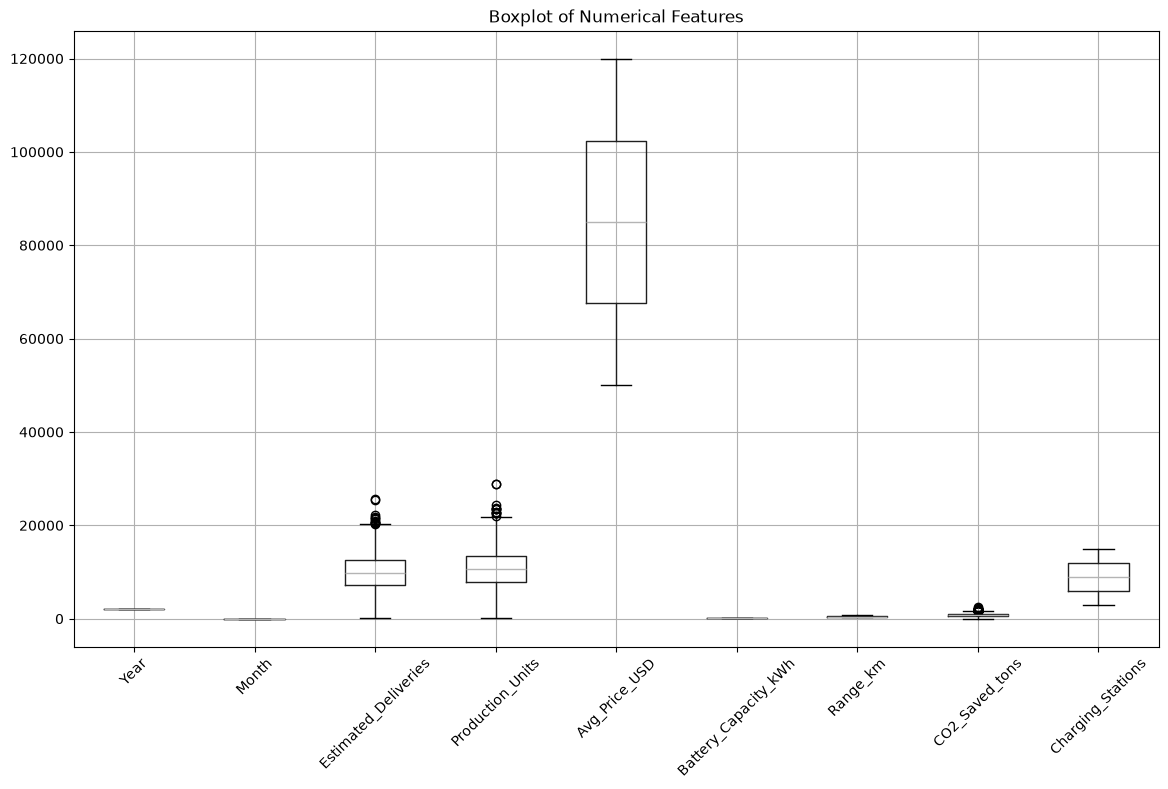

In [83]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(14,8))
df[numeric_cols].boxplot(rot=45)
plt.title("Boxplot of Numerical Features")
plt.show()

Correlation Matrix

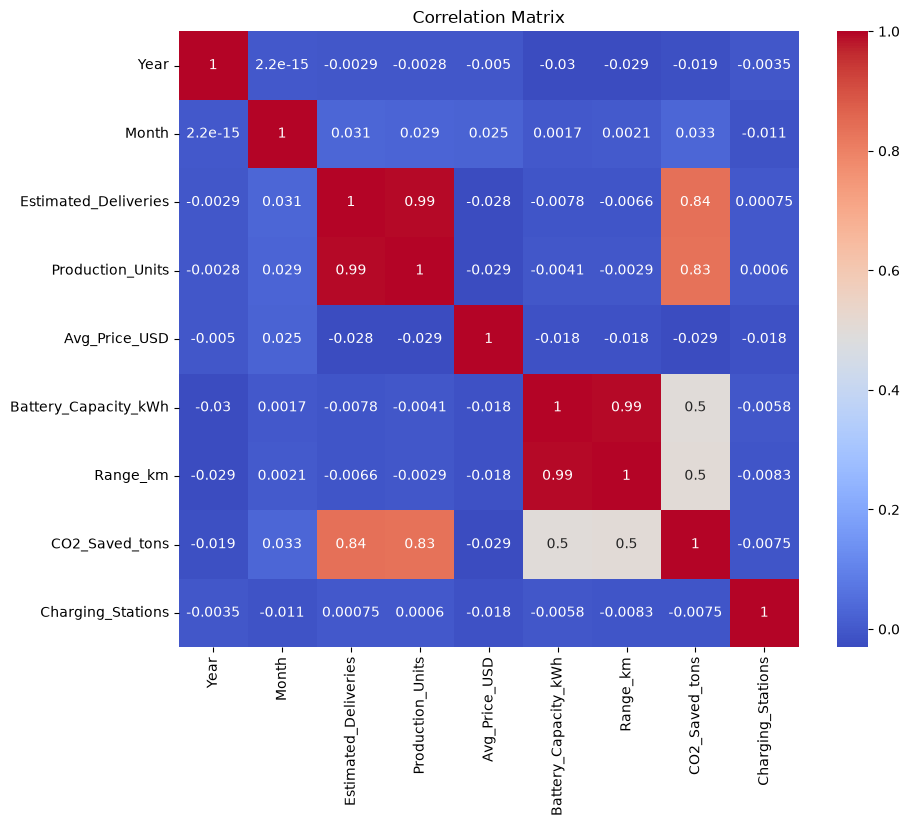

In [84]:
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### Data Quality Assessment Summary

The dataset was assessed for quality before proceeding with analysis and modeling.

**Observations:**
- No missing values were found in any column.
- No duplicate records were present in the dataset.
- All features have appropriate data types.
- A few outliers were observed in `Estimated_Deliveries`, `Production_Units`, and `CO2_Saved_tons`. Since these values may represent valid business observations, they were retained.
- Strong correlations were observed between:
  - `Estimated_Deliveries` and `Production_Units` (0.99)
  - `Battery_Capacity_kWh` and `Range_km` (0.99)
- These highly correlated features will be considered during feature engineering and model development to avoid potential multicollinearity or data leakage.

**Conclusion:**

The dataset is clean, complete, and suitable for further exploratory data analysis and machine learning.

## 4. Exploratory Data Analysis (EDA)

The objective of EDA is to understand the data, identify trends and patterns, and answer business questions through visualization.

Target Variable Distribution

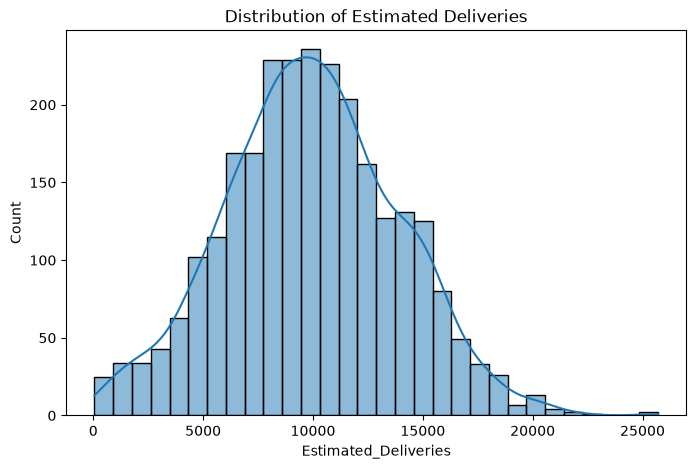

In [85]:
plt.figure(figsize=(8,5))
sns.histplot(df["Estimated_Deliveries"], bins=30, kde=True)
plt.title("Distribution of Estimated Deliveries")
plt.show()

Deliveries by Region

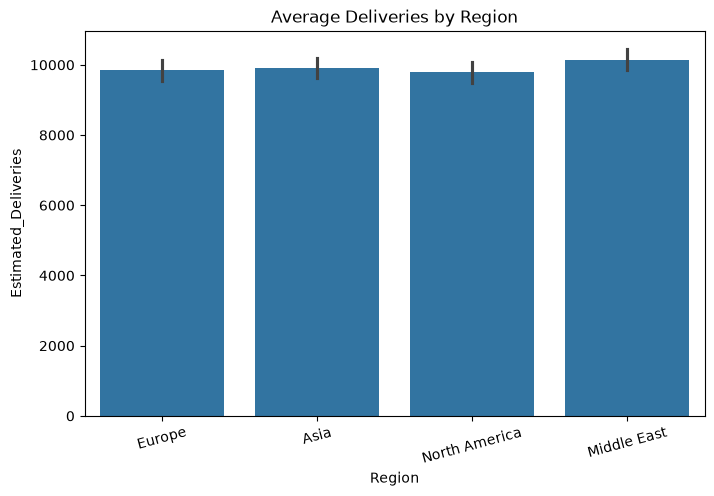

In [86]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Region", y="Estimated_Deliveries", estimator="mean")
plt.title("Average Deliveries by Region")
plt.xticks(rotation=15)
plt.show()

Deliveries by Model

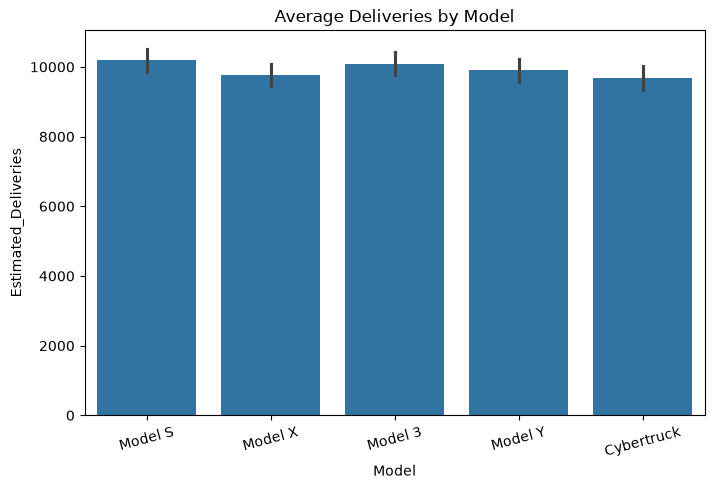

In [87]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Model", y="Estimated_Deliveries", estimator="mean")
plt.title("Average Deliveries by Model")
plt.xticks(rotation=15)
plt.show()

Monthly Trend

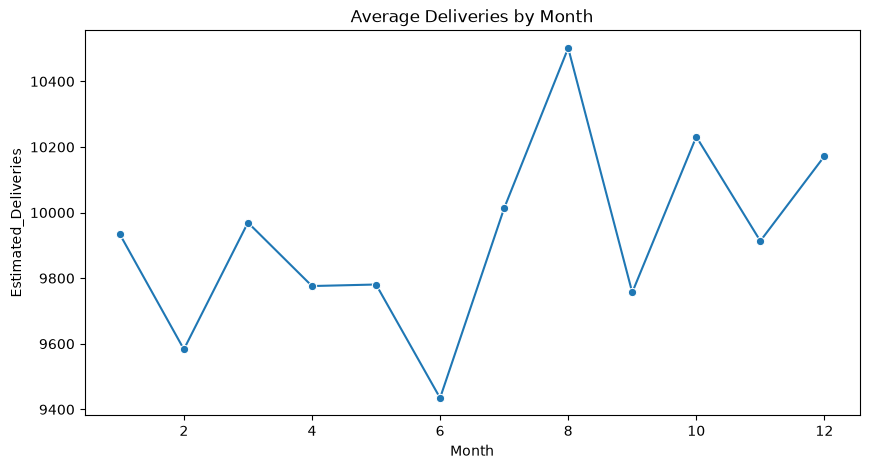

In [88]:
monthly = df.groupby("Month")["Estimated_Deliveries"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=monthly, x="Month", y="Estimated_Deliveries", marker="o")
plt.title("Average Deliveries by Month")
plt.show()

Yearly Trend

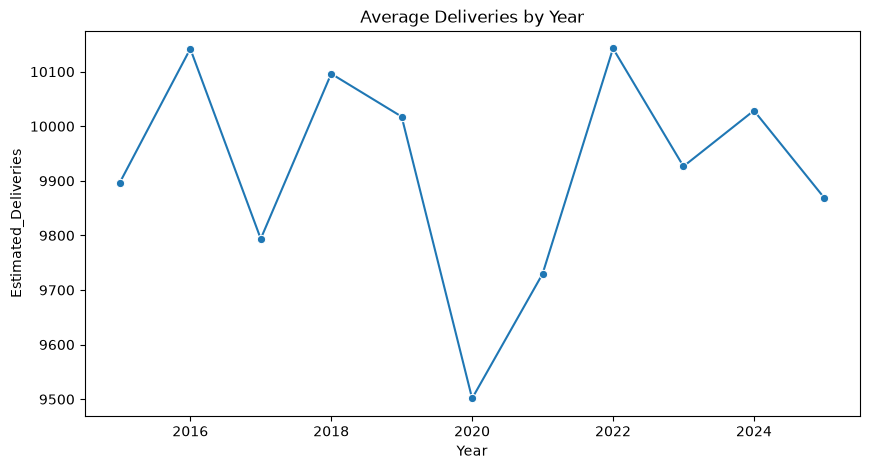

In [89]:
yearly = df.groupby("Year")["Estimated_Deliveries"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=yearly, x="Year", y="Estimated_Deliveries", marker="o")
plt.title("Average Deliveries by Year")
plt.show()

Price vs Deliveries

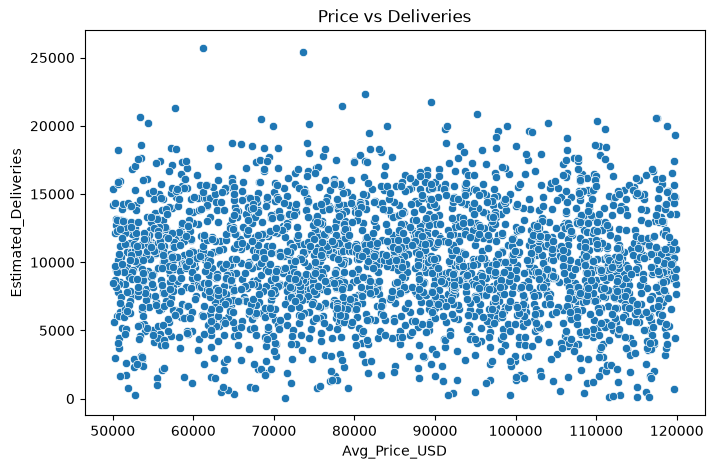

In [90]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Avg_Price_USD", y="Estimated_Deliveries")
plt.title("Price vs Deliveries")
plt.show()

Production vs Deliveries

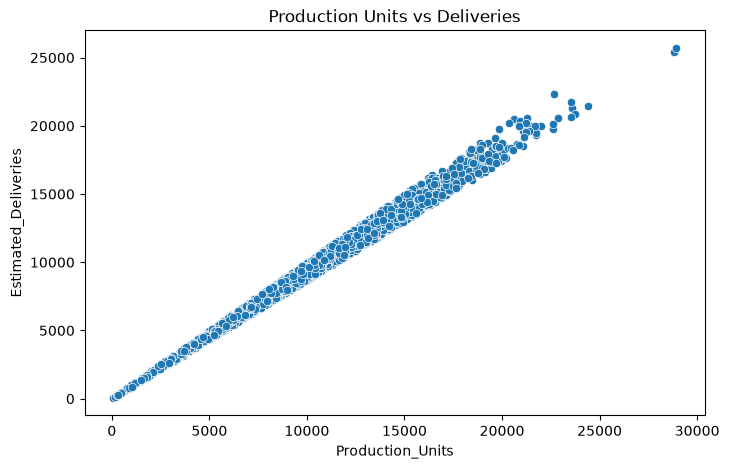

In [91]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Production_Units", y="Estimated_Deliveries")
plt.title("Production Units vs Deliveries")
plt.show()

### EDA Summary

**Key Observations:**

- The distribution of `Estimated_Deliveries` is approximately normal with a slight right skew.
- Average deliveries are fairly similar across all regions, with the Middle East showing a slightly higher average.
- Model S and Model 3 have the highest average deliveries, while Cybertruck has the lowest.
- Monthly deliveries fluctuate throughout the year, indicating possible seasonal patterns.
- Yearly deliveries remain relatively stable with minor variations across years.
- There is little to no relationship between `Avg_Price_USD` and `Estimated_Deliveries`.
- `Production_Units` has a very strong positive linear relationship with `Estimated_Deliveries`, making it one of the most influential predictors.
- The correlation analysis confirms that `Production_Units` is highly correlated with the target variable, while `Battery_Capacity_kWh` and `Range_km` are also strongly correlated with each other.

### Conclusion

The EDA shows that production volume is the strongest predictor of deliveries, while pricing has minimal impact. Seasonal trends and vehicle characteristics may also contribute to prediction performance and will be explored further during feature engineering.

In [92]:
df[["Estimated_Deliveries", "Production_Units"]].head(20)

,Estimated_Deliveries,Production_Units
0,17646,17922
1,3797,4164
2,8411,9189
3,6555,7311
4,12374,13537
5,4656,5043
6,7717,7976
7,8410,9192
8,15145,15760
9,7790,8208


In [93]:
(df["Production_Units"] - df["Estimated_Deliveries"]).describe()

count    2640.000000
mean      733.647727
std       546.600800
min         0.000000
25%       294.000000
50%       635.500000
75%      1068.000000
max      3392.000000
dtype: float64

### Production Units Analysis

The comparison between `Production_Units` and `Estimated_Deliveries` shows that production is consistently higher than deliveries, with an average difference of approximately **734 units**.

This indicates a very strong relationship between the two variables, which is also reflected in the correlation coefficient (0.99). Although `Production_Units` is a valuable predictor, its availability at prediction time may not always be guaranteed in real-world scenarios.

To evaluate its impact, two regression models will be developed:

- **Model 1:** Excluding `Production_Units` to simulate a real-world forecasting scenario.
- **Model 2:** Including `Production_Units` to evaluate the maximum predictive performance.

The performance of both models will be compared using standard regression evaluation metrics.

## 5. Feature Engineering

Feature engineering is the process of creating new features from existing data to improve model performance and capture meaningful business patterns.

Create Date Feature

In [94]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str) + "-01"
)

Create Quarter

In [95]:
df["Quarter"] = df["Date"].dt.quarter

Create Season

In [96]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)

Revenue

In [97]:
df["Revenue"] = (
    df["Estimated_Deliveries"] *
    df["Avg_Price_USD"]
)

Price per km

In [98]:
df["Price_per_km"] = (
    df["Avg_Price_USD"] /
    df["Range_km"]
)

Delivery Efficiency

In [99]:
df["Delivery_Efficiency"] = (
    df["Estimated_Deliveries"] /
    df["Production_Units"]
)

Check New Features

In [100]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,Season,Revenue,Price_per_km,Delivery_Efficiency
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01,2,Spring,1.638859e+09,131.923679,0.984600
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01,1,Winter,2.361949e+08,142.022032,0.911864
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01,1,Winter,9.915502e+08,245.598583,0.915334
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01,1,Winter,5.853281e+08,125.414199,0.896594
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01,4,Winter,1.421114e+09,173.747020,0.914087


In [101]:
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations', 'Date', 'Quarter',
       'Season', 'Revenue', 'Price_per_km', 'Delivery_Efficiency'],
      dtype='str')

### Feature Engineering Summary

The following new features were created:

- **Date:** Combines Year and Month for time series analysis.
- **Quarter:** Captures quarterly business trends.
- **Season:** Represents seasonal demand patterns.
- **Revenue:** Estimated revenue generated from vehicle deliveries.
- **Price_per_km:** Indicates the price paid per kilometer of driving range.
- **Delivery_Efficiency:** Measures the ratio of deliveries to production units.

These engineered features provide additional business insights and may improve the predictive performance of the machine learning models.

### Note on Target Leakage

Two additional features, **Revenue** and **Delivery_Efficiency**, were created for business analysis and visualization. However, these features were **excluded from the regression models** because they are derived from the target variable (`Estimated_Deliveries`).

Including them as input features would introduce **target leakage**, leading to unrealistically high model performance. Therefore, they are used only for EDA and business insights, not for model training.

## 6. Data Preparation for Machine Learning

Before training the models, the dataset is prepared by selecting the target variable, defining input features, splitting the data chronologically, and creating preprocessing pipelines for numerical and categorical features.

Two regression models will be developed:

- **Model 1:** Excludes `Production_Units` to simulate a real-world forecasting scenario.
- **Model 2:** Includes `Production_Units` to evaluate its impact on prediction performance.

The preprocessing pipeline handles missing values, feature scaling, and categorical encoding to ensure a consistent and reusable workflow.

Define Target Variable

In [102]:
target = "Estimated_Deliveries"

Build Two Datasets

Model 1 (Without Production Units)

In [103]:
X1 = df.drop(columns=[
    "Estimated_Deliveries",
    "Production_Units",      # Removed
    "Revenue",               # Target Leakage
    "Delivery_Efficiency",   # Target Leakage
    "Date"                   # Only for Time Series
])

y = df[target]

Model 2 (With Production Units)

In [104]:
X2 = df.drop(columns=[
    "Estimated_Deliveries",
    "Revenue",
    "Delivery_Efficiency",
    "Date"
])

y = df[target]

Identify Feature Types

In [105]:
categorical_features = [
    "Region",
    "Model",
    "Source_Type",
    "Season"
]

numerical_features_model1 = [
    "Year",
    "Month",
    "Avg_Price_USD",
    "Battery_Capacity_kWh",
    "Range_km",
    "CO2_Saved_tons",
    "Charging_Stations",
    "Quarter",
    "Price_per_km"
]

numerical_features_model2 = numerical_features_model1 + [
    "Production_Units"
]

Train-Test Split (Chronological)

In [106]:
train_size = int(len(df) * 0.8)

X1_train = X1.iloc[:train_size]
X1_test = X1.iloc[train_size:]

X2_train = X2.iloc[:train_size]
X2_test = X2.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

Preprocessing Pipeline

In [107]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [108]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

Preprocessor for Model 1

In [109]:
preprocessor1 = ColumnTransformer([
    ("num", numeric_transformer, numerical_features_model1),
    ("cat", categorical_transformer, categorical_features)
])

Preprocessor for Model 2

In [110]:
preprocessor2 = ColumnTransformer([
    ("num", numeric_transformer, numerical_features_model2),
    ("cat", categorical_transformer, categorical_features)
])

## 7. Baseline Model - Linear Regression

Linear Regression is used as the baseline model because it is simple, interpretable, and provides a benchmark against which more complex models can be compared.

Two models are trained:
- **Model 1:** Without `Production_Units`
- **Model 2:** With `Production_Units`

Model 1 (Without Production Units)

In [111]:
pipeline_lr_1 = Pipeline([
    ("preprocessor", preprocessor1),
    ("model", LinearRegression())
])

pipeline_lr_1.fit(X1_train, y_train)

pred_lr_1 = pipeline_lr_1.predict(X1_test)

Model 2 (With Production Units)

In [112]:
pipeline_lr_2 = Pipeline([
    ("preprocessor", preprocessor2),
    ("model", LinearRegression())
])

pipeline_lr_2.fit(X2_train, y_train)

pred_lr_2 = pipeline_lr_2.predict(X2_test)

Evaluation Function

In [113]:
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return pd.Series({
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    })

Evaluate Both Models

In [114]:
lr_results = pd.DataFrame({
    "Without Production Units": evaluate_model(y_test, pred_lr_1),
    "With Production Units": evaluate_model(y_test, pred_lr_2)
})

lr_results

,Without Production Units,With Production Units
MAE,668.606859,311.944385
MSE,884327.569250,143945.636645
RMSE,940.386925,379.401682
R2 Score,0.942356,0.990617


Residual Plot (Model 2)

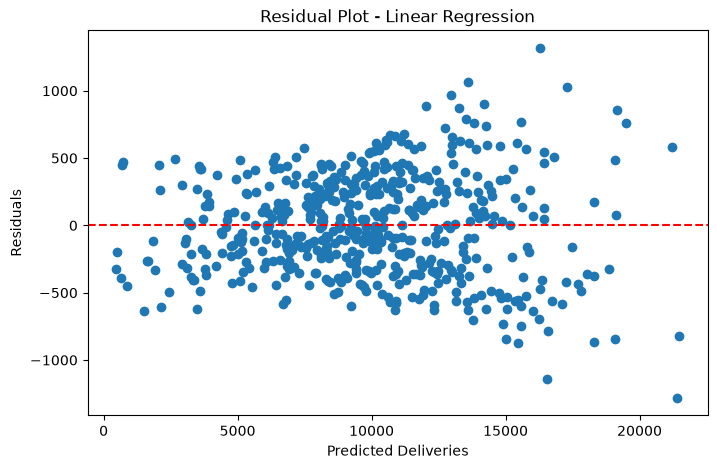

In [115]:
residuals = y_test - pred_lr_2

plt.figure(figsize=(8,5))
plt.scatter(pred_lr_2, residuals)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Deliveries")
plt.ylabel("Residuals")
plt.title("Residual Plot - Linear Regression")
plt.show()

### Baseline Model Summary

Linear Regression was used as the baseline model to establish an initial performance benchmark.

The performance of both models was compared to evaluate the impact of including `Production_Units` as a predictor. This comparison helps assess whether the additional feature improves predictive performance while considering its practical availability in real-world forecasting scenarios.

### Results and Observations

The baseline Linear Regression models achieved strong predictive performance.

- The model **without `Production_Units`** achieved an **R² score of 0.942**, indicating that the remaining features are effective predictors of vehicle deliveries.
- The model **with `Production_Units`** achieved an **R² score of 0.991**, showing a significant improvement due to the strong relationship between production and deliveries.
- The residual plot shows that prediction errors are generally centered around zero, indicating that the model does not exhibit significant bias. A slight increase in residual spread is observed for higher predicted values, suggesting mild heteroscedasticity.

Overall, including `Production_Units` improves prediction accuracy substantially. However, the model without this feature may be more suitable for real-world forecasting when production data is unavailable.

### Model Selection Strategy

To compare different machine learning algorithms, the model **including `Production_Units`** will be used because it achieved the best baseline performance. The objective of this stage is to identify the best-performing algorithm, which will then be further optimized using hyperparameter tuning.

## 8. Model Comparison

In this step, multiple regression algorithms are trained and evaluated using the same preprocessed dataset. Their performance is compared using MAE, RMSE, and R² Score to identify the best-performing model.

Import Models

In [116]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

Create Model Dictionary

In [117]:
models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        random_state=42,
        objective="reg:squarederror"
    ),

    "LightGBM": LGBMRegressor(
        random_state=42
    )
}

Train and Evaluate All Models

In [118]:
results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor2),
        ("model", model)
    ])

    pipeline.fit(X2_train, y_train)

    predictions = pipeline.predict(X2_test)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
        "R2 Score": r2_score(y_test, predictions)
    })

results_df = pd.DataFrame(results)
results_df.sort_values(by="R2 Score", ascending=False)

,Model,MAE,RMSE,R2 Score
5,LightGBM,239.420962,310.475994,0.993717
4,XGBoost,228.586258,310.913561,0.993699
0,Linear Regression,311.944385,379.401682,0.990617
3,Gradient Boosting,308.966557,382.305331,0.990473
2,Random Forest,302.779091,386.650489,0.990255
1,Decision Tree,386.617424,520.280814,0.982355


Visualize Model Performance

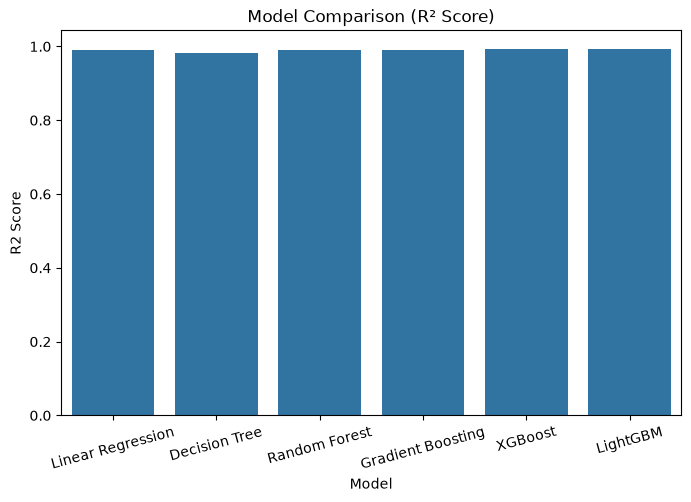

In [119]:
plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x="Model", y="R2 Score")
plt.xticks(rotation=15)
plt.title("Model Comparison (R² Score)")
plt.show()

Find Best Model

In [120]:
best_model = results_df.sort_values(
    by="R2 Score",
    ascending=False
).iloc[0]

best_model

Model         LightGBM
MAE         239.420962
RMSE        310.475994
R2 Score      0.993717
Name: 5, dtype: object

### Model Comparison Summary

Six regression algorithms were evaluated using the same preprocessing pipeline and evaluation metrics.

| Model | R² Score |
|--------|----------|
| LightGBM | **0.9937** |
| XGBoost | **0.9937** |
| Linear Regression | 0.9906 |
| Gradient Boosting | 0.9905 |
| Random Forest | 0.9903 |
| Decision Tree | 0.9824 |

Among all the evaluated models, **LightGBM** achieved the highest R² score and the lowest RMSE, making it the best-performing model for this dataset.

Therefore, LightGBM has been selected as the final model for hyperparameter tuning.

## 9. Hyperparameter Tuning

To further improve model performance, the best-performing model (LightGBM) is optimized using **RandomizedSearchCV**. This approach efficiently searches different hyperparameter combinations while reducing computational cost.

Import

In [121]:
from sklearn.model_selection import RandomizedSearchCV

Parameter Grid

In [122]:
param_grid = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 5, 7, 10],
    "model__num_leaves": [20, 31, 50, 70],
    "model__subsample": [0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.8, 0.9, 1.0]
}

Pipeline

In [123]:
lgb_pipeline = Pipeline([
    ("preprocessor", preprocessor2),
    ("model", LGBMRegressor(
    random_state=42,
    verbose=-1
))
])

RandomizedSearchCV

In [124]:
random_search = RandomizedSearchCV(
    estimator=lgb_pipeline,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X2_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...verbose=-1))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.8, 0.9, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``Randomiz

Best Parameters

In [125]:
random_search.best_params_

{'model__subsample': 1.0,
 'model__num_leaves': 20,
 'model__n_estimators': 200,
 'model__max_depth': 7,
 'model__learning_rate': 0.1,
 'model__colsample_bytree': 0.8}

Best Score

In [126]:
random_search.best_score_

np.float64(0.9922264914917008)

Test Performance

In [127]:
best_lgb = random_search.best_estimator_

pred = best_lgb.predict(X2_test)

tuned_results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2 Score"],
    "Value": [
        mean_absolute_error(y_test, pred),
        np.sqrt(mean_squared_error(y_test, pred)),
        r2_score(y_test, pred)
    ]
})

tuned_results

,Metric,Value
0,MAE,212.374553
1,RMSE,277.163583
2,R2 Score,0.994993


Compare Before vs After

In [128]:
comparison = pd.DataFrame({
    "Before Tuning": [
        239.420962,
        310.475994,
        0.993717
    ],
    "After Tuning": [
        mean_absolute_error(y_test, pred),
        np.sqrt(mean_squared_error(y_test, pred)),
        r2_score(y_test, pred)
    ]
}, index=["MAE", "RMSE", "R2 Score"])

comparison

,Before Tuning,After Tuning
MAE,239.420962,212.374553
RMSE,310.475994,277.163583
R2 Score,0.993717,0.994993


Save Best Model

In [129]:
joblib.dump(best_lgb, "best_lightgbm_pipeline.pkl")

['best_lightgbm_pipeline.pkl']

### Hyperparameter Tuning Results

RandomizedSearchCV was used to optimize the LightGBM model.

**Best Hyperparameters**

- Number of Estimators: **200**
- Learning Rate: **0.1**
- Maximum Depth: **7**
- Number of Leaves: **20**
- Subsample: **1.0**
- Column Sample by Tree: **0.8**

### Performance Comparison

| Metric | Before Tuning | After Tuning |
|--------|--------------:|-------------:|
| MAE | 239.42 | **212.37** |
| RMSE | 310.48 | **277.16** |
| R² Score | 0.9937 | **0.9950** |

The tuned LightGBM model achieved lower prediction errors and a higher R² score compared to the default model. Therefore, the tuned LightGBM model was selected as the final regression model.

## 10. Model Explainability

Model explainability helps us understand how different features influence the model's predictions. This improves transparency, builds trust, and provides valuable business insights.

Feature Importance

In [130]:
feature_names = best_lgb.named_steps["preprocessor"].get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_lgb.named_steps["model"].feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
9,num__Production_Units,1054
5,num__CO2_Saved_tons,912
4,num__Range_km,608
8,num__Price_per_km,197
6,num__Charging_Stations,180
2,num__Avg_Price_USD,178
3,num__Battery_Capacity_kWh,137
0,num__Year,104
1,num__Month,86
19,cat__Source_Type_Estimated (Region),27


Plot Top 15 Features

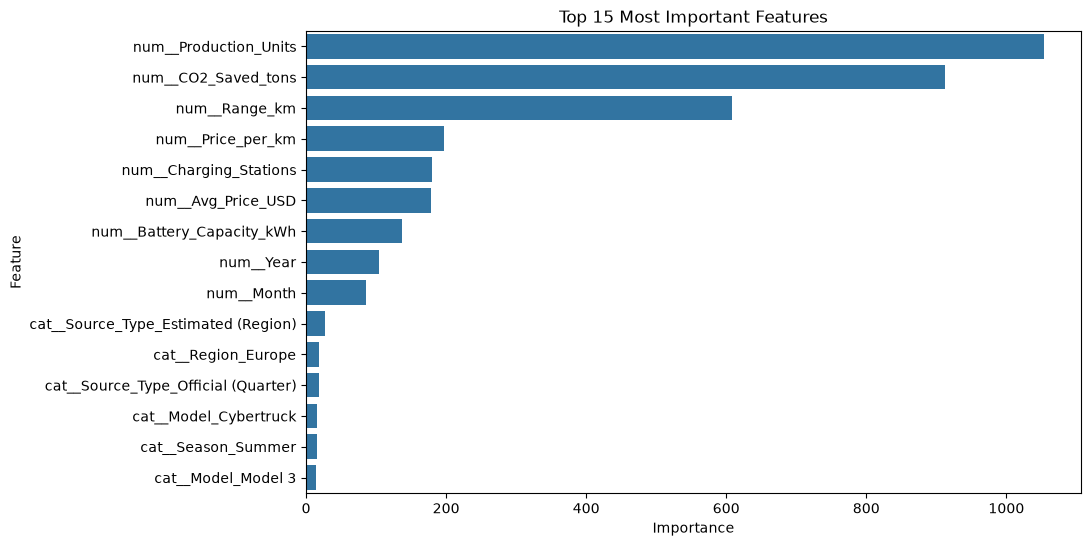

In [131]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Most Important Features")

plt.show()

### Feature Importance Summary

The tuned LightGBM model identifies the most influential features for predicting Tesla vehicle deliveries.

#### Key Observations

- **Production_Units** is the most important feature, indicating that vehicle production strongly influences deliveries.
- **CO2_Saved_tons** is the second most important feature, suggesting that environmental impact is associated with delivery patterns.
- **Range_km** also has a significant impact, implying that vehicles with higher driving range tend to have different delivery trends.
- **Price_per_km**, **Charging_Stations**, and **Avg_Price_USD** have moderate importance, showing that pricing and charging infrastructure also contribute to demand.
- **Year** and **Month** capture temporal trends, while categorical features such as **Region**, **Model**, and **Source_Type** have relatively smaller contributions.

Overall, production capacity and vehicle characteristics are the primary drivers of Tesla deliveries in this dataset.

## 11. Time Series Forecasting

In addition to regression modeling, a time series forecasting model is built to predict future Tesla deliveries based on historical monthly delivery trends. ARIMA is used as a baseline forecasting model.

In [132]:
monthly_sales = (
    df.groupby(["Year", "Month"])["Estimated_Deliveries"]
      .sum()
      .reset_index()
)

monthly_sales["Date"] = pd.to_datetime(
    monthly_sales["Year"].astype(str) + "-" +
    monthly_sales["Month"].astype(str)
)

monthly_sales = monthly_sales.sort_values("Date")

monthly_sales.head()

,Year,Month,Estimated_Deliveries,Date
0,2015,1,183180,2015-01-01
1,2015,2,165053,2015-02-01
2,2015,3,184567,2015-03-01
3,2015,4,225623,2015-04-01
4,2015,5,184264,2015-05-01


Set Date as Index

In [133]:
monthly_sales = monthly_sales.set_index("Date")

ts = monthly_sales["Estimated_Deliveries"]

ts.head()

Date
2015-01-01    183180
2015-02-01    165053
2015-03-01    184567
2015-04-01    225623
2015-05-01    184264
Name: Estimated_Deliveries, dtype: int64

Train ARIMA

In [134]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(ts, order=(1,1,1))

arima_model = model.fit()

print(arima_model.summary())

                                SARIMAX Results                                 
Dep. Variable:     Estimated_Deliveries   No. Observations:                  132
Model:                   ARIMA(1, 1, 1)   Log Likelihood               -1488.634
Date:                  Sat, 27 Jun 2026   AIC                           2983.269
Time:                          23:48:08   BIC                           2991.895
Sample:                      01-01-2015   HQIC                          2986.774
                           - 12-01-2025                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1592      0.074      2.158      0.031       0.015       0.304
ma.L1         -0.7277      0.063    -11.529      0.000      -0.851      -0.604
sigma2       3.58e+08   1.93e-11   1

Forecast Next 12 Months

In [135]:
forecast = arima_model.forecast(steps=12)

forecast

2026-01-01    201130.711313
2026-02-01    199815.368224
2026-03-01    199605.917016
2026-04-01    199572.564647
2026-05-01    199567.253718
2026-06-01    199566.408022
2026-07-01    199566.273356
2026-08-01    199566.251912
2026-09-01    199566.248497
2026-10-01    199566.247953
2026-11-01    199566.247867
2026-12-01    199566.247853
Freq: MS, Name: predicted_mean, dtype: float64

Plot Forecast

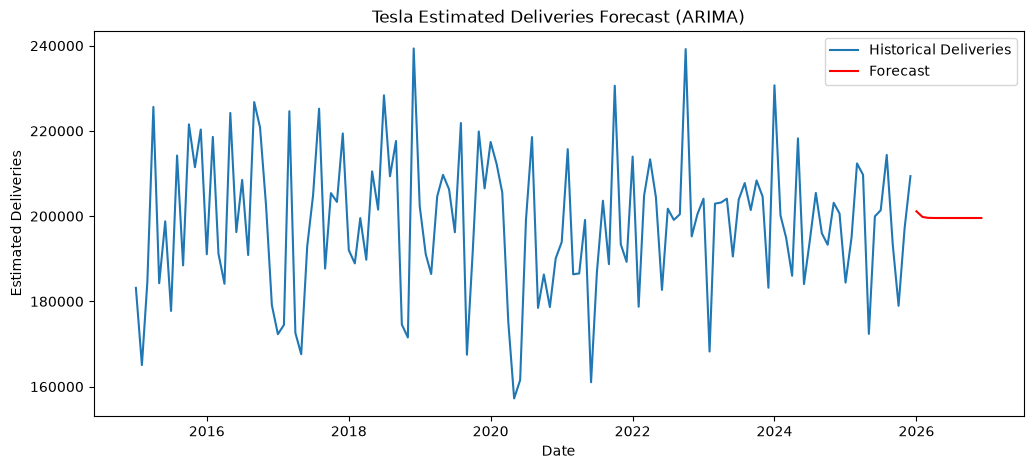

In [136]:
plt.figure(figsize=(12,5))

plt.plot(ts, label="Historical Deliveries")

forecast_index = pd.date_range(
    start=ts.index[-1] + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)

plt.plot(
    forecast_index,
    forecast,
    label="Forecast",
    color="red"
)

plt.title("Tesla Estimated Deliveries Forecast (ARIMA)")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.legend()

plt.show()

### Time Series Forecasting Summary

An ARIMA(1,1,1) model was trained on the monthly Estimated Deliveries data to forecast future Tesla deliveries.

#### Key Observations

- The model forecasts deliveries to stabilize around **199,500–200,000 vehicles per month** over the next year.
- The forecast indicates a relatively stable delivery trend with no strong upward or downward movement.
- This forecast can help production, inventory, and supply chain teams estimate future demand and plan resources accordingly.

ARIMA serves as a statistical baseline forecasting model, while the LightGBM regression model provides more accurate predictions by utilizing additional business features.

## 12. Business Recommendations

Based on the exploratory data analysis, feature engineering, machine learning models, and time series forecasting, the following business recommendations can be made:

- Increase production capacity during periods of high expected demand since **Production_Units** is the strongest predictor of deliveries.
- Focus on improving vehicle range and battery technology, as these features significantly influence deliveries.
- Expand charging infrastructure to encourage EV adoption in different regions.
- Monitor pricing strategies to maintain competitiveness while maximizing demand.
- Use monthly demand forecasts for production planning, inventory management, and logistics optimization.

## 13. Production Mindset

To deploy this solution in a production environment, the following workflow can be implemented:

1. Collect new sales and production data automatically.
2. Apply the same preprocessing and feature engineering pipeline.
3. Load the saved LightGBM pipeline.
4. Generate delivery predictions for new data.
5. Monitor model performance using MAE, RMSE, and R².
6. Retrain the model periodically as new data becomes available.
7. Detect data drift and update the model when prediction accuracy decreases.

This approach ensures the model remains reliable and scalable for real-world business use.

# Conclusion

In this project, an end-to-end machine learning pipeline was developed to predict Tesla vehicle deliveries using historical sales, production, pricing, and vehicle specifications.

The project included:

- Business understanding
- Data quality assessment
- Exploratory Data Analysis (EDA)
- Feature engineering
- Data preprocessing
- Regression model comparison
- Hyperparameter tuning
- Model explainability
- Time series forecasting using ARIMA
- Business recommendations
- Production deployment considerations

Among all evaluated models, the tuned **LightGBM Regressor** achieved the best performance with:

- **MAE:** 212.37
- **RMSE:** 277.16
- **R² Score:** 0.9950

The final solution demonstrates a production-oriented machine learning workflow capable of supporting data-driven decision-making for demand forecasting, production planning, and inventory management.